# P0 · Read, run, inspect

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.1 · Read, run, inspect

A notebook keeps values between runs. Inspect the current values and rerun dependencies when they change.

**Prerequisites:** Basic variables, loops and functions.

**Predict:** After reassigning text, does an already calculated length update?

**Mental model:** A model notebook is a program with memory. A cell reads values left by earlier executions, even when the visible order looks different.

### Why this operation exists

A model notebook is a program with memory. A cell reads values left by earlier executions, even when the visible order looks different.

Watch a text variable and a separate length variable. Assigning the length calculates an integer at that moment; it does not attach a live formula to the text.

Now change the text without running the length calculation again. Predict whether the stored length follows the new text automatically.

Inspecting both values makes the mismatch visible. Reading code means tracking execution order and current state, as well as understanding individual lines.

Begin experiments with a restart and run all. That makes hidden dependencies visible before they affect a model result.

### Follow the values

The source contains the letters t and o, a space, b and e, and a newline. The representation exposes that otherwise hidden newline.

Counting this source gives 6 positions. The integer is stored under the name length.

Reassign text to the shorter phrase without its newline. The source now contains 5 positions, but no length calculation has run.

The stored integer is still 6. Changing one name does not automatically recompute another name that was calculated from it.

Run the length expression again. Its result now matches the current text. Choose the longer phrase in the lab and repeat the same reasoning.

In [3]:
FRAMES.clear()
change = 0
text = "to be\n"
show("Source text", repr(text))
length = len(text)
show("Count including the newline", length)
text = "to be or not" if change else "to be"
show("Reassigned text", repr(text))
show("Old length is still stored", length)
length = len(text)
show("Recomputed length", length)

Source text: "'to be\\n'"
Count including the newline: 6
Reassigned text: "'to be'"
Old length is still stored: 6
Recomputed length: 5


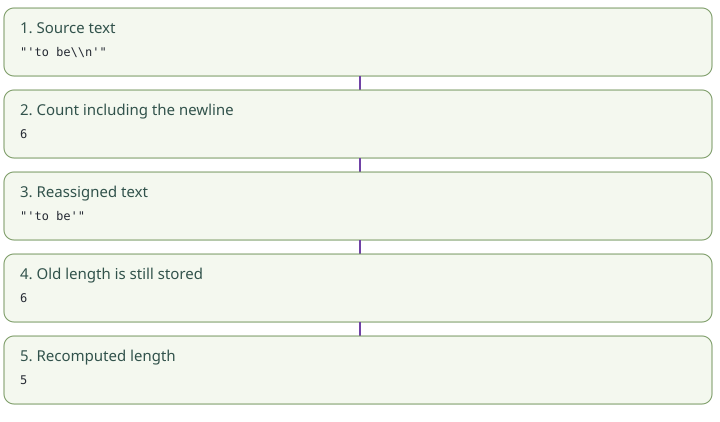

In [4]:
draw_trace()

### Read the implementation

Read the assignment to text first. Quotes create a string, and the backslash escape represents a newline inside it.

The function len returns the number of positions in the string. The show helper prints a named intermediate value for this notebook.

The conditional expression chooses the experiment input. Its purpose is to change one cause while leaving the remaining lines identical.

Two calls inspect the new text and the previously stored integer. Print is an observation; it does not repair a stale calculation.

Recompute length explicitly. If execution fails, read the exception type and the last relevant line of the traceback before changing the program.

### Change one thing

**Use a longer replacement string**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be\n"
show("Source text", repr(text))
length = len(text)
show("Count including the newline", length)
text = "to be or not" if change else "to be"
show("Reassigned text", repr(text))
show("Old length is still stored", length)
length = len(text)
show("Recomputed length", length)

Source text: "'to be\\n'"
Count including the newline: 6
Reassigned text: "'to be or not'"
Old length is still stored: 6
Recomputed length: 12


### A useful distinction

A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.

In [6]:
sample = "a\nb"
assert len(sample) == 3 and repr(sample) == "'a\\nb'"
try:
    len(3)
except TypeError as error:
    print(type(error).__name__, str(error))
print("A traceback identifies the operation and the values it could not accept.")

TypeError object of type 'int' has no len()
A traceback identifies the operation and the values it could not accept.


### ✋ Your turn

Reassign text to "hello", then calculate its current length in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 5, 'A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
text = "hello"
answer = len(text)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 5, 'A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.'
    print("✓ right:", answer)

✓ right: 5


### Reconnect to the transformer

Training code calculates batches, predictions and loss in an order. A previous loss value can remain in notebook memory after you change the batch.

Imports create names too. The alias torch refers to a module, while model refers to a particular object you constructed.

Inspect type, shape and a small sample at a boundary. These observations tell you what the next operation will actually receive.

A reproducible notebook runs from its first setup cell to its last result after restarting the kernel. Printed output from an older execution is not evidence of a new one.

This habit prepares every later experiment. Next, inspect the positions and boundaries inside the text itself.

```python
batch = get_batch()
logits, loss = model(*batch)
print(loss.item())
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** After reassigning text, does an already calculated length update?

<details><summary>Check your explanation</summary>

No; run the calculation again. A printed result can belong to an earlier execution. Restart and run all before trusting a notebook result.

</details>